<a href="https://colab.research.google.com/github/Haridharshan15/Artificial-Intelligence/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Build Single Nural Network Construction**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



In [ ]:
data=keras.datasets.mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#data description
print(data[0][0].shape)

(60000, 28, 28)


In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = data

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [ ]:
# 1. Build the neural network architecture
model = keras.Sequential([
    # Hidden Layer: 128 neurons, ReLU activation.
    # input_shape must match your flattened 28x28 images (784,)
    layers.Dense(128, activation='relu', input_shape=(784,)),

    # Optional: You can add more hidden layers here if you want a deeper network
    # layers.Dense(64, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9), Softmax activation
    layers.Dense(10, activation='softmax')
])

# 2. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. View the architecture and parameter count
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. Train the model
print("Starting training...")
history = model.fit(x_train,
                    y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.2)



Starting training...
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9216 - loss: 0.2809 - val_accuracy: 0.9548 - val_loss: 0.1557
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9632 - loss: 0.1261 - val_accuracy: 0.9659 - val_loss: 0.1130
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9751 - loss: 0.0860 - val_accuracy: 0.9654 - val_loss: 0.1068
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9808 - loss: 0.0644 - val_accuracy: 0.9727 - val_loss: 0.0916
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9849 - loss: 0.0496 - val_accuracy: 0.9697 - val_loss: 0.1013



Evaluating on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9724 - loss: 0.0886
Test Accuracy: 0.9724


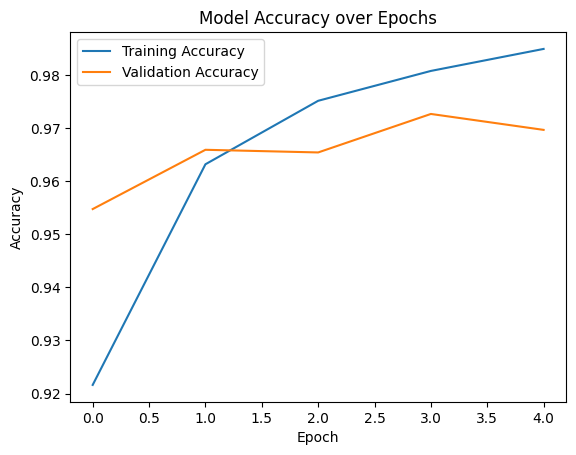

In [ ]:
# 5. Evaluate on test data
print("\nEvaluating on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 6. Plot the training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(x_test)

import numpy as np
print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
7


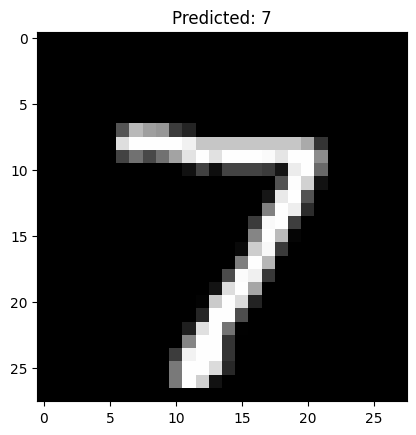

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.show()

#**Build Multi Nural Network Construction**

In [ ]:
# Build a Deep Neural Network (DNN)
deep_model = keras.Sequential([
    # Input layer implicitly defined by input_shape

    # 1st Hidden Layer: 256 neurons
    layers.Dense(256, activation='relu', input_shape=(784,)),
    # Dropout layer: randomly turns off 20% of neurons during training
    layers.Dropout(0.2),

    # 2nd Hidden Layer: 128 neurons
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    # 3rd Hidden Layer: 64 neurons
    layers.Dense(64, activation='relu'),
    # Note: We usually don't put dropout right before the output layer

    # Output Layer: 10 neurons for digits 0-9
    layers.Dense(10, activation='softmax')
])

# Compile the new model
deep_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the deep model
print("Starting training for the deep model...")
history = deep_model.fit(x_train,
                         y_train,
                         epochs=5,
                         batch_size=64, # Slightly larger batch size for the deeper network
                         validation_split=0.2)

# Evaluate the model on the unseen test data
print("\nEvaluating on test data...")
test_loss, test_acc = deep_model.evaluate(x_test, y_test)
print(f"Deep Model Test Accuracy: {test_acc:.4f}")



Starting training for the deep model...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8959 - loss: 0.3427 - val_accuracy: 0.9632 - val_loss: 0.1298
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9564 - loss: 0.1446 - val_accuracy: 0.9643 - val_loss: 0.1128
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9669 - loss: 0.1076 - val_accuracy: 0.9719 - val_loss: 0.0939
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9728 - loss: 0.0875 - val_accuracy: 0.9730 - val_loss: 0.0965
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9763 - loss: 0.0752 - val_accuracy: 0.9749 - val_loss: 0.0892

Evaluating on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0751
Deep Model Test Accuracy: 0.9781


#Predition

In [ ]:
predictions = deep_model.predict(x_test)

import numpy as np
print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


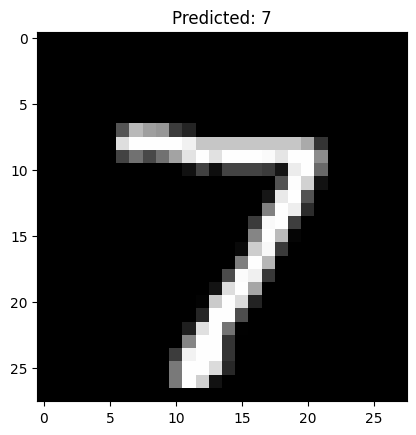

In [ ]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.show()

or we can try this code for prediction too

In [ ]:
# Predict a single sample
# Let's pick the very first image in the test set
sample_index = 0
sample_image = x_test[sample_index] # This currently has a shape of (784,)
true_label = y_test[sample_index]

# Keras models expect a "batch" of inputs, even if it's just one image.
# So, we reshape our (784,) array into a (1, 784) array.
sample_batch = sample_image.reshape(1, 784)

# Make the prediction
# This returns an array of 10 probabilities (one for each digit)
prediction_probs = deep_model.predict(sample_batch)

# Find the index of the highest probability
predicted_digit = np.argmax(prediction_probs)

print(f"\n--- Prediction Results ---")
print(f"True Label: {true_label}")
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence (Probability): {prediction_probs[0][predicted_digit] * 100:.2f}%")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

--- Prediction Results ---
True Label: 7
Predicted Digit: 7
Confidence (Probability): 100.00%


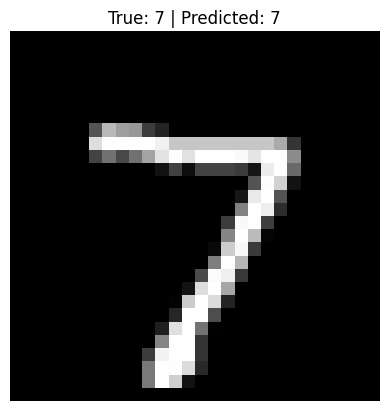

In [ ]:
# Visualize the single prediction
# We must reshape the flattened 784-pixel array back to 28x28 to draw it
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_digit}")
plt.axis('off') # Hides the axis ticks
plt.show()



#**early stopping**

In [ ]:
# 1. Define the Early Stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',          # We want to watch the validation loss
    patience=3,                  # How many epochs to wait before stopping if there's no improvement
    restore_best_weights=True    # CRITICAL: Roll back to the best weights, not the weights at the stopped epoch
)

# 2. Train the model and pass the callback
print("Starting training with Early Stopping...")
history = deep_model.fit(x_train,
                         y_train,
                         epochs=50,      # We can set a huge number of epochs now safely!
                         batch_size=64,
                         validation_split=0.2,
                         callbacks=[early_stopping]) # Add the callback here

Starting training with Early Stopping...
Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9789 - loss: 0.0655 - val_accuracy: 0.9723 - val_loss: 0.0963
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9818 - loss: 0.0580 - val_accuracy: 0.9792 - val_loss: 0.0802
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9845 - loss: 0.0503 - val_accuracy: 0.9788 - val_loss: 0.0799
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9859 - loss: 0.0444 - val_accuracy: 0.9772 - val_loss: 0.0912
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9857 - loss: 0.0434 - val_accuracy: 0.9806 - val_loss: 0.0848
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9871 - loss: 0.0389 - val_accuracy: 0.9788 - val_loss: 0.0819


In [ ]:
print("\nEvaluating the deep model on test data...")
test_loss, test_acc = deep_model.evaluate(x_test, y_test)
print(f"Deep Model Test Accuracy: {test_acc:.4f}")


Evaluating the deep model on test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9807 - loss: 0.0674
Deep Model Test Accuracy: 0.9807


In [ ]:
# Make the prediction
# This returns an array of 10 probabilities (one for each digit)
prediction_probs = deep_model.predict(sample_batch)

# Find the index of the highest probability
predicted_digit = np.argmax(prediction_probs)

print(f"\n--- Prediction Results ---")
print(f"True Label: {true_label}")
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence (Probability): {prediction_probs[0][predicted_digit] * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

--- Prediction Results ---
True Label: 7
Predicted Digit: 7
Confidence (Probability): 100.00%
